In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from utils import tx_rx_system

## Anàlisi de l'Emisor

En aquesta etapa del projecte, ens centrem en el comportament del senyal enviat pel nostre LED driver. L'objectiu és validar que el circuit respon correctament a la freqüència de treball.

### 1. Generació del Senyal de Pols (1 kHz)

Per començar l'anàlisi, simulem la transmissió d'un senyal quadrat. Aquest senyal representa les dades digitals que volem transmetre.
Paràmetres de la Simulació:
- Freqüència: $1\text{ kHz}$ (període de $1\text{ ms}$).
- Amplitud: $3.3\text{ V}$ (nivell lògic estàndard).
- Cicle de treball (Duty Cycle): $50\%$.

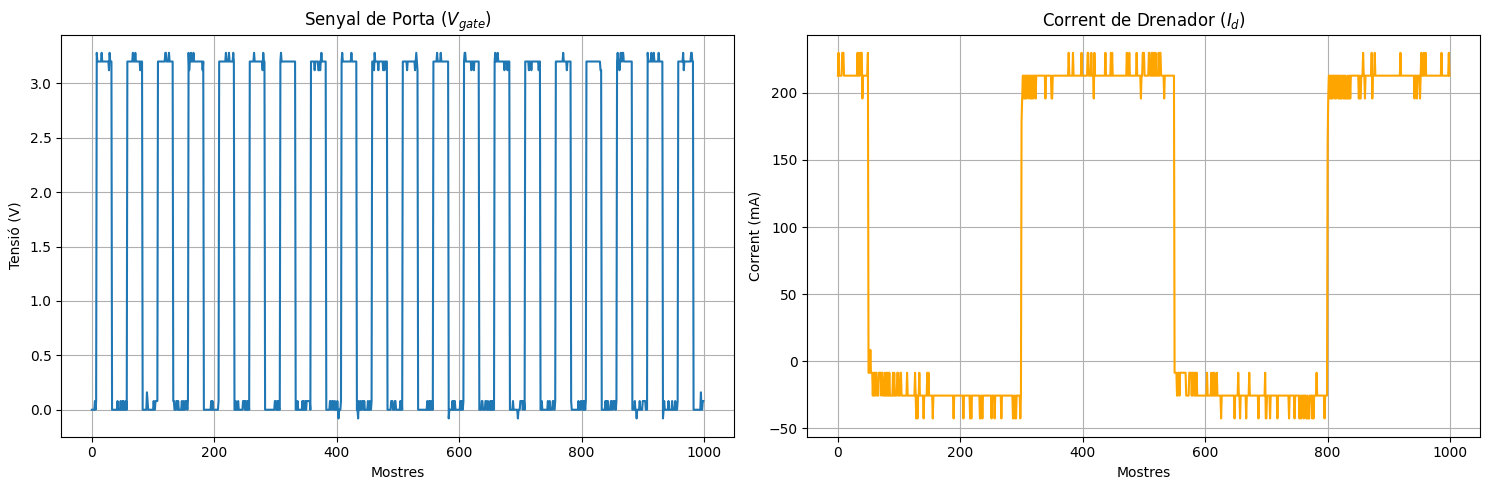

In [8]:
tx_rx_system.convertir_senyal_osciloscopi("fitxers/1kHz_V_gate.csv", "fitxers/1kHz_V_gate_neta.csv", channels=1)
tx_rx_system.convertir_senyal_osciloscopi("fitxers/1kHz_Id.csv", "fitxers/1kHz_Id_neta.csv", channels=1)

signal_gate = np.loadtxt("fitxers/1kHz_V_gate_neta.csv", delimiter=',')
v_mesurada = np.loadtxt("fitxers/1kHz_Id_neta.csv", delimiter=',')

resistencia = 4.7  # Ohms -- L'has mesurada?! 
signal_Id = ((5 - v_mesurada) / resistencia) * 1000  # Els 5V els has mesurat? A tenir en compte: Això és mesura indirecte de la intensitat del corrent elèctric, la precisió depèn de la precisió d' V i R

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(signal_gate[:1000])
ax1.set_title("Senyal de Porta ($V_{gate}$)")
ax1.set_xlabel("Mostres") # Si acaba a la memòria, estaria bé passar de mostres a temps
ax1.set_ylabel("Tensió (V)")
ax1.grid(True)

ax2.plot(signal_Id[:1000], color='orange')
ax2.set_title("Corrent de Drenador ($I_d$)")
ax2.set_xlabel("Mostres")
ax2.set_ylabel("Corrent (mA)")
ax2.grid(True)
plt.tight_layout()
plt.show()

#### Interpretació del resultat

### 2. Generació del Senyal de Pols (1 MHz)

En aquesta secció simulem la transmissió d'un senyal quadrat al sistema.

- Freqüència: 1 MHz.
- Amplitud: 3.3V.
- Objectiu: Demostrar que a aquesta freqüència, el voltatge $V_{gate}$ no té prou temps per carregar-se i assolir pràcticament els 3.3V.


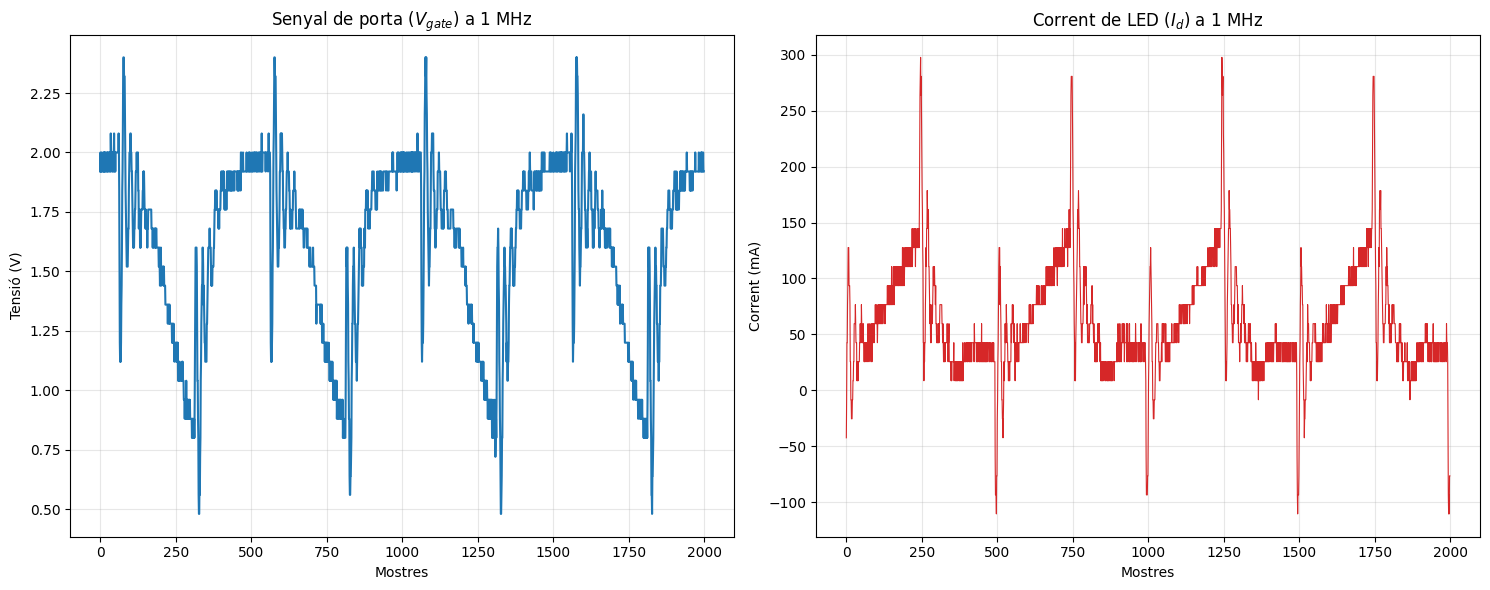

In [9]:
tx_rx_system.convertir_senyal_osciloscopi(
    senyal_csv="fitxers/1MHz_V_gate.csv",
    senyal_neta_csv="fitxers/1MHz_V_gate_neta.csv",
    channels=1
)
tx_rx_system.convertir_senyal_osciloscopi(
    senyal_csv="fitxers/1MHz_Id.csv",
    senyal_neta_csv="fitxers/1MHz_Id_neta.csv",
    channels=1
)

signal_gate = np.loadtxt("fitxers/1MHz_V_gate_neta.csv", delimiter=',')
v_mesurada = np.loadtxt("fitxers/1MHz_Id_neta.csv", delimiter=',')

signal_Id = ((5 - v_mesurada) / resistencia) * 1000
# A tenir en compte: aquí assumeixes que els "5V" no depenen de la freqüència i no és veritat
# e.g., les inducatàncies parasites (L_p) del circuit (+ la que afegeix l'oscil.) + el on-off del driver (di/dt) creen pics de corrent segons freq
# Voltage que cau a R: V(t) = I(t) * R + L_p * di(t)/dt
# La menera més precisa seria mesurar els "5V" amb l'altre canal de l'oscil.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(signal_gate[:2000], color='tab:blue')
ax1.set_title("Senyal de porta ($V_{gate}$) a 1 MHz")
ax1.set_xlabel("Mostres")
ax1.set_ylabel("Tensió (V)")
ax1.grid(True, alpha=0.3)
ax2.plot(signal_Id[:2000], color='tab:red', linewidth=0.8)
ax2.set_title("Corrent de LED ($I_d$) a 1 MHz")
ax2.set_xlabel("Mostres")
ax2.set_ylabel("Corrent (mA)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Interpretació del resultat

### 3. Sweep de freqüència (de 1 kHz a 7.5 MHz) amb senyal de pols quadrat

En aquest apartat es realitza un sweep de freqüència, és a dir, una variació progressiva de la freqüència del senyal d’entrada des de 1 kHz fins a 7.5 MHz, mantenint la resta de paràmetres constants (amplitud i forma del senyal).

#### Objectiu:

L’objectiu principal és analitzar el comportament dinàmic del sistema davant diferents velocitats de commutació, i determinar fins a quina freqüència el sistema és capaç de respondre correctament.

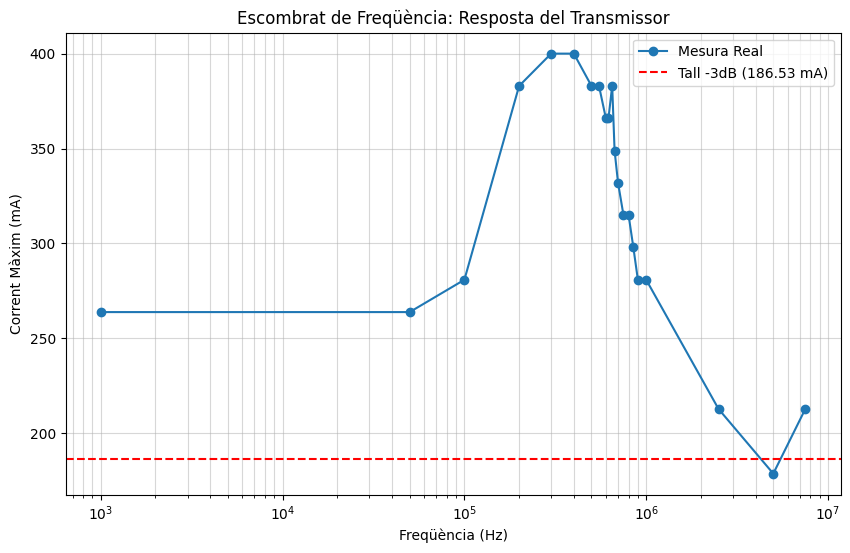

In [10]:
freqs = [
    1000, 50000, 100000, 200000, 300000, 400000, 500000, 
    550000, 600000, 620000, 650000, 670000, 700000, 750000, 800000, 
    850000, 900000, 1000000, 2500000, 5000000, 7500000
]
senyals = ["a","b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l", "m", "n", "o", "p", "q", "r", "s", "t", "u"]


max_currents = []
for senyal in senyals:
    tx_rx_system.convertir_senyal_osciloscopi(
        senyal_csv=f"fitxers/BW/{senyal}.csv",
        senyal_neta_csv=f"fitxers/BW/{senyal}_neta.csv",
        channels=1
    )
    v_mesurada = np.loadtxt(f"fitxers/BW/{senyal}_neta.csv", delimiter=',')
    signal_Id = ((5 - v_mesurada) / resistencia) * 1000
    max_currents.append(np.max(signal_Id))


i_base = max_currents[0]    # NOTA: No hi ha criteri en el codi per comprobar que és aquest el valor de referència que vols
i_cutoff = i_base * 0.707   # NOTA: Tall -3dB pel càlcul de l'amplada de banda elèctrica, NO òptica

plt.figure(figsize=(10, 6))
plt.semilogx(freqs, max_currents, 'o-', label='Mesura Real')
plt.axhline(y=i_cutoff, color='r', linestyle='--', label=f'Tall -3dB ({i_cutoff:.2f} mA)')
plt.title("Escombrat de Freqüència: Resposta del Transmissor")
plt.xlabel("Freqüència (Hz)")
plt.ylabel("Corrent Màxim (mA)")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

Després del primer sweep de freqüència, s’observa que els resultats obtinguts no són del tot correctes ni representatius del comportament real del sistema.

Això es deu al fet que apareixen pics d’overshoot en el senyal de sortida, tal com es pot veure en els gràfics següents:

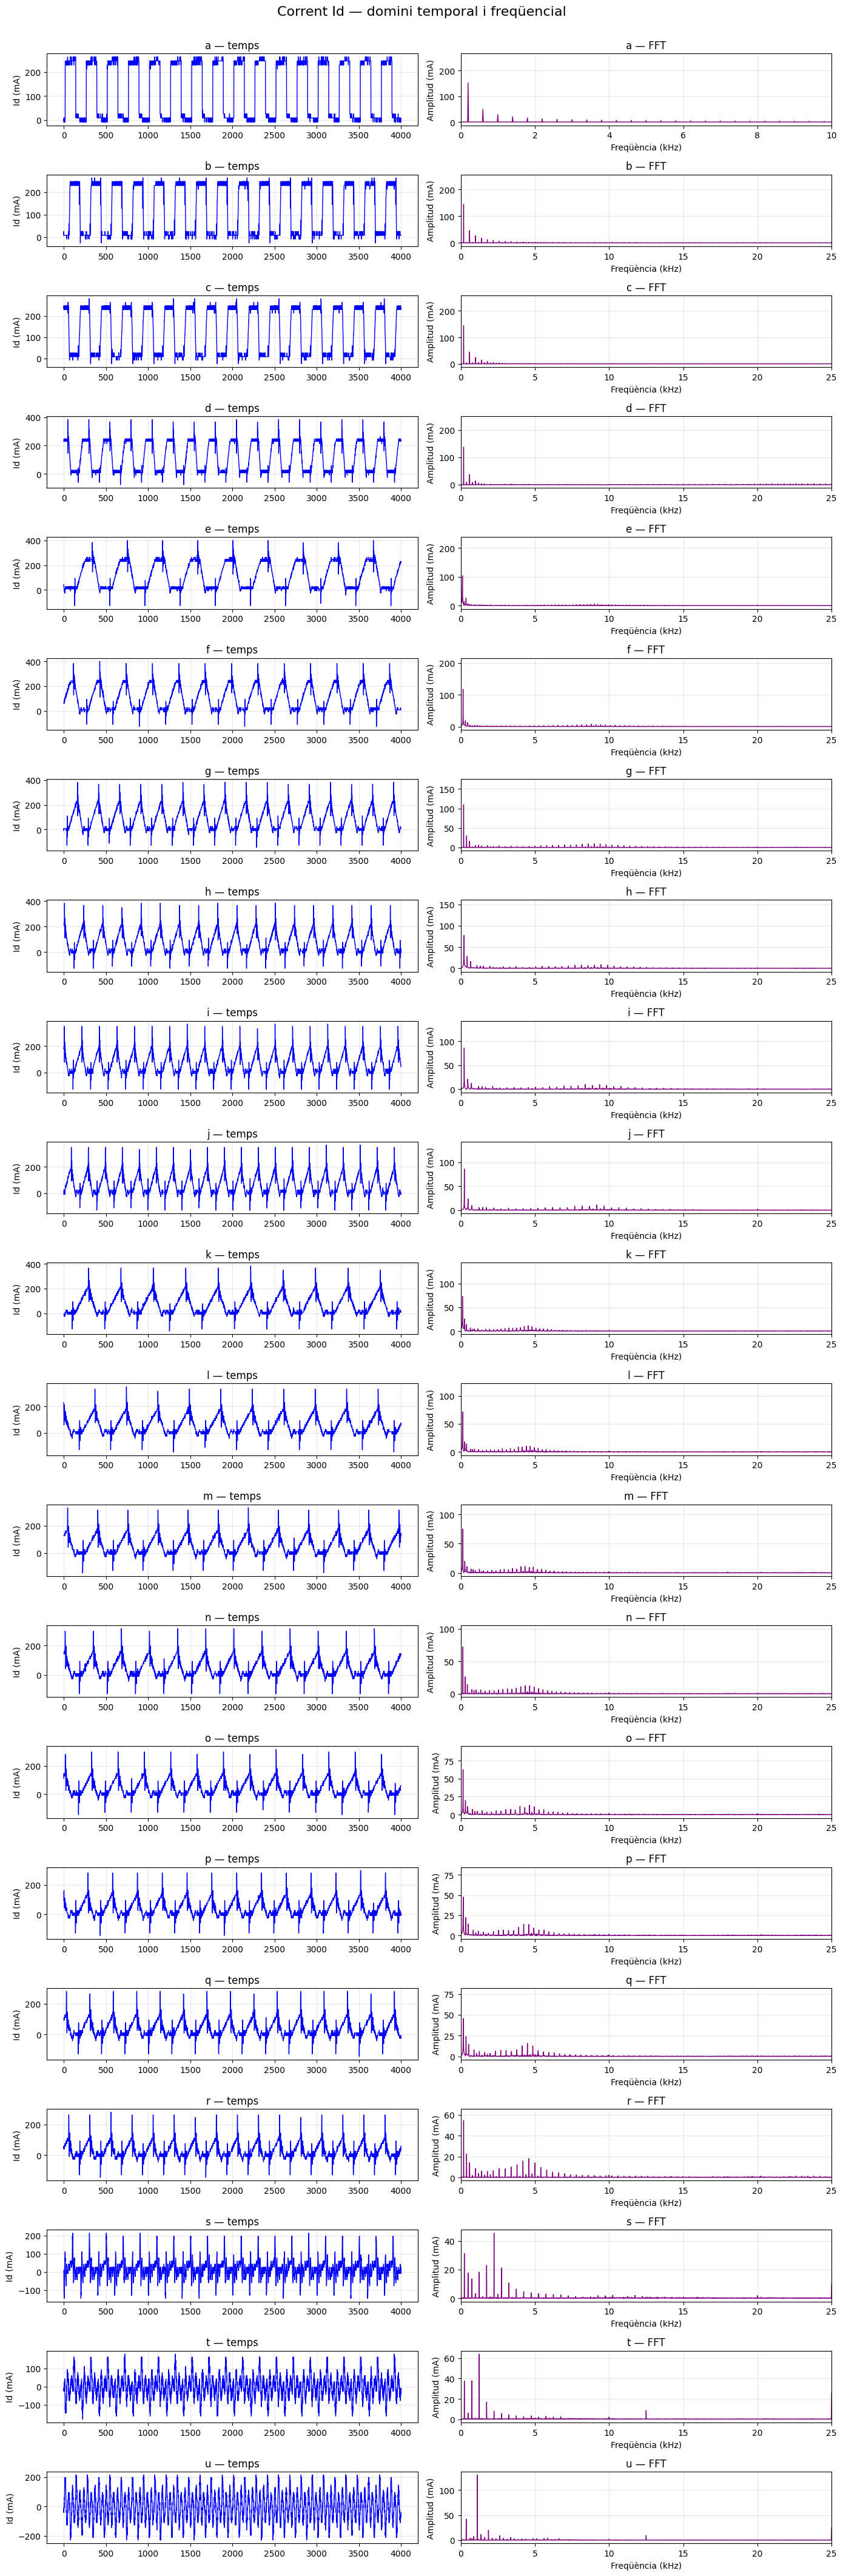

In [11]:

# EXPERIMENT A REPETRIR PK NO VIAG AMPUNTAR LES SAMPLING RATES
fs = 50000 #de l'oscil.loscopi
max_currents = []
fig, axes = plt.subplots(nrows=len(senyals), ncols=2, figsize=(14, len(senyals) * 2))
for i, (senyal, freq) in enumerate(zip(senyals, freqs)):
    v_mesurada = np.loadtxt(f"fitxers/BW/{senyal}_neta.csv", delimiter=',')
    signal_Id  = ((5 - v_mesurada) / resistencia) * 1000
    N  = len(signal_Id)

    # --- time domain ---
    ax_t = axes[i, 0]
    ax_t.plot(signal_Id, color='blue', linewidth=1)
    ax_t.set_title(f"{senyal} — temps")
    ax_t.set_ylabel("Id (mA)")
    ax_t.grid(True, alpha=0.3)

    # --- FFT ---
    ax_f = axes[i, 1]
    spectrum  = np.abs(np.fft.rfft(signal_Id))        
    freqs_fft = np.fft.rfftfreq(N, d=1/fs)          
    amplitude = 2 * spectrum / N                   
    
    idx_fund = np.argmin(np.abs(freqs_fft - freq))
    valor_estable = amplitude[idx_fund]

    max_currents.append(valor_estable)

    ax_f.plot(freqs_fft / 1e3, amplitude, color='purple', linewidth=1)  # x in kHz

    ax_f.set_title(f"{senyal} — FFT")
    ax_f.set_xlabel("Freqüència (kHz)")
    ax_f.set_ylabel("Amplitud (mA)")
    ax_f.set_xlim(0, min(freqs_fft[-1] / 1e3, freq * 10 / 1e3))  
    ax_f.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle("Corrent Id — domini temporal i freqüencial", fontsize=16, y=1.01)
plt.show()

# UN COP TINGUI TOTS ELS VALORS ESTABLES, JA ES POT FER EL PLOT DE BANDA AMB AQUESTS VALORS

És per aquest motiu que, per tal d'obtenir una mesura més representativa del comportament real del sistema, s'opta per filtrar la component de contínua (DC) i extraient únicament l'amplitud corresponent a la freqüència fonamental del senyal d'excitació.

## Anàlisi del Sistema Complet (TX I RX amb sensor MAX3012)
